In [ ]:
import zipfile
import os

zip_file_name = 'labels.zip'

# Распаковка
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('/content/')

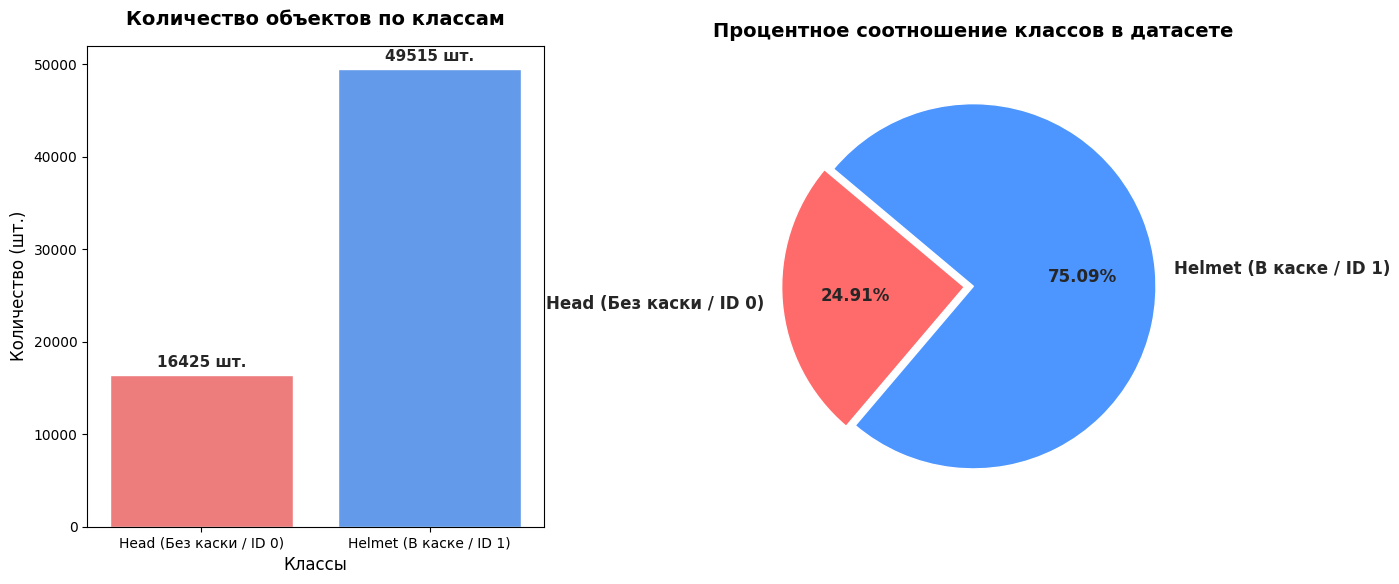

Всего объектов: 65940
Касок (ID 1): 49515 шт. (75.09%)
Голов (ID 0): 16425 шт. (24.91%)


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

paths_to_check = [
    'labels',
    'labels_1'
]

def analyze_and_plot_classes(directories):
    total_helmets = 0
    total_heads = 0

    # Сбор статистики
    for directory in directories:
        if os.path.exists(directory):
            for file in os.listdir(directory):
                if file.endswith('.txt'):
                    with open(os.path.join(directory, file), 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if parts:
                                class_id = int(parts[0])
                                if class_id == 1:
                                    total_helmets += 1
                                elif class_id == 0:
                                    total_heads += 1

    total_objects = total_helmets + total_heads

    if total_objects == 0:
        print("Данные не найдены! Проверь пути к папкам.")
        return

    # Данные для графиков
    classes = ['Head (Без каски / ID 0)', 'Helmet (В каске / ID 1)']
    counts = [total_heads, total_helmets]
    colors = ['#FF6B6B', '#4D96FF'] # Красный для голов, Синий для касок

    # Настройка графиков (делаем сетку 1 строка, 2 колонки)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.set_theme(style="whitegrid")

    # 1. Столбчатая диаграмма (Гистограмма распределения)
    sns.barplot(x=classes, y=counts, ax=axes[0], palette=colors, hue=classes, legend=False)
    axes[0].set_title('Количество объектов по классам', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_ylabel('Количество (шт.)', fontsize=12)
    axes[0].set_xlabel('Классы', fontsize=12)

    # Добавляем значения над столбцами
    for i, count in enumerate(counts):
        axes[0].text(i, count + (max(counts) * 0.01), f'{count} шт.', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # 2. Круговая диаграмма (Процентное соотношение)
    axes[1].pie(counts, labels=classes, autopct='%1.2f%%', startangle=140, colors=colors,
                textprops={'fontsize': 12, 'weight': 'bold'}, explode=(0.05, 0))
    axes[1].set_title('Процентное соотношение классов в датасете', fontsize=14, fontweight='bold', pad=15)

    # Отображение
    plt.tight_layout()
    plt.show()

    # Вывод в консоль для подстраховки
    print(f"Всего объектов: {total_objects}")
    print(f"Касок (ID 1): {total_helmets} шт. ({(total_helmets/total_objects)*100:.2f}%)")
    print(f"Голов (ID 0): {total_heads} шт. ({(total_heads/total_objects)*100:.2f}%)")

# Запуск генерации графиков
analyze_and_plot_classes(paths_to_check)

Количество объектов по классам:
         head  helmet
Train   1803    4863
Test   14622   44652


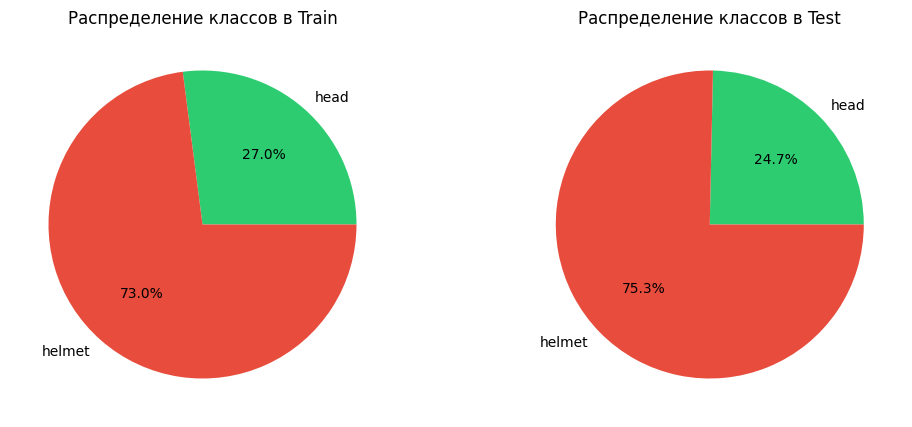

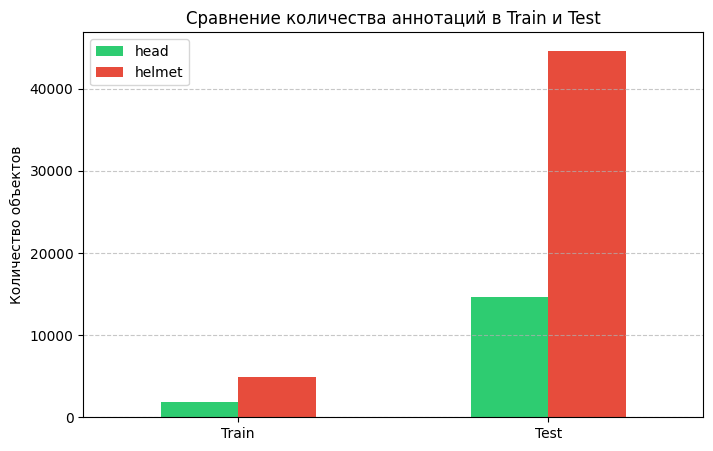

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd

train_labels_dir = 'labels'
test_labels_dir = 'labels_1'
classes = {1: 'helmet', 0: 'head'}

def count_classes(directory):
    counts = {0: 0, 1: 0}
    if not os.path.exists(directory):
        return counts
    for file in os.listdir(directory):
        if file.endswith('.txt'):
            with open(os.path.join(directory, file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        cls_id = int(parts[0])
                        if cls_id in counts:
                            counts[cls_id] += 1
    return counts

# Сбор данных
train_counts = count_classes(train_labels_dir)
test_counts = count_classes(test_labels_dir)

df = pd.DataFrame([train_counts, test_counts], index=['Train', 'Test']).rename(columns=classes)
print("Количество объектов по классам:\n", df)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].pie(df.loc['Train'], labels=df.columns, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axs[0].set_title('Распределение классов в Train')

axs[1].pie(df.loc['Test'], labels=df.columns, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axs[1].set_title('Распределение классов в Test')
plt.show()

df.plot(kind='bar', figsize=(8, 5), color=['#2ecc71', '#e74c3c'])
plt.title('Сравнение количества аннотаций в Train и Test')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:

train_labels_dir = 'labels'
test_labels_dir = 'labels_1'

def count_classes(directory):
    counts = {0: 0, 1: 0}
    if not os.path.exists(directory):
        return counts
    for file in os.listdir(directory):
        if file.endswith('.txt'):
            with open(os.path.join(directory, file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        cls_id = int(parts[0])
                        if cls_id in counts:
                            counts[cls_id] += 1
    return counts

# Сбор данных
train_counts = count_classes(train_labels_dir)
test_counts = count_classes(test_labels_dir)

# Создание и красивое форматирование таблицы
df_table = pd.DataFrame([
    {'ID класса': 1, 'Название класса': 'helmet', 'Кол-во аннотаций (train)': train_counts[1], 'Кол-во аннотаций (test)': test_counts[1]},
    {'ID класса': 0, 'Название класса': 'head', 'Кол-во аннотаций (train)': train_counts[0], 'Кол-во аннотаций (test)': test_counts[0]}
])

# Вывод таблицы
print("Таблица. Распределение аннотаций по классам")
display(df_table.to_string(index=False))

Таблица. Распределение аннотаций по классам


' ID класса Название класса  Кол-во аннотаций (train)  Кол-во аннотаций (test)\n         1          helmet                      4863                    44652\n         0            head                      1803                    14622'

In [ ]:
paths_to_check = [
    'labels',
    'labels_1'
]

def count_classes_corrected(directories):
    total_helmets = 0
    total_heads = 0
    total_files = 0

    for directory in directories:
        if not os.path.exists(directory):
            print(f"Предупреждение: Путь {directory} не найден, пропускаем.")
            continue

        for file in os.listdir(directory):
            if file.endswith('.txt'):
                total_files += 1
                with open(os.path.join(directory, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            # Первое число в строке YOLO — это ID класса
                            class_id = int(parts[0])

                            # ИСПРАВЛЕНО: теперь 1 - это каска, 0 - голова
                            if class_id == 1:
                                total_helmets += 1
                            elif class_id == 0:
                                total_heads += 1

    total_objects = total_helmets + total_heads

    print("=" * 50)
    print(f"РЕЗУЛЬТАТЫ ПОДСЧЕТА ОБЪЕКТОВ (ИСПРАВЛЕННЫЕ ИНДЕКСЫ):")
    print(f"Проанализировано файлов разметки: {total_files}")
    print("-" * 50)
    if total_objects > 0:
        pct_helmet = (total_helmets / total_objects) * 100
        pct_head = (total_heads / total_objects) * 100
        print(f"Класс 1 (helmet / В КАСКЕ):  {total_helmets} шт. ({pct_helmet:.2f}%)")
        print(f"Класс 0 (head / БЕЗ КАСКИ):  {total_heads} шт. ({pct_head:.2f}%)")
        print("-" * 50)
        print(f"Всего размеченных объектов: {total_objects} шт.")
    else:
        print("В указанных папках объекты не найдены.")
    print("=" * 50)

# Запуск правильного подсчета
count_classes_corrected(paths_to_check)

РЕЗУЛЬТАТЫ ПОДСЧЕТА ОБЪЕКТОВ (ИСПРАВЛЕННЫЕ ИНДЕКСЫ):
Проанализировано файлов разметки: 17573
--------------------------------------------------
Класс 1 (helmet / В КАСКЕ):  49515 шт. (75.09%)
Класс 0 (head / БЕЗ КАСКИ):  16425 шт. (24.91%)
--------------------------------------------------
Всего размеченных объектов: 65940 шт.


In [ ]:
train_labels_dir = 'labels'
test_labels_dir = 'labels_1'

def get_combined_density_stats(train_dir, test_dir):
    total_objects_per_frame = []

    # Собираем данные из обеих директорий
    for directory in [train_dir, test_dir]:
        if os.path.exists(directory):
            for file in os.listdir(directory):
                if file.endswith('.txt'):
                    objs_in_file = 0
                    with open(os.path.join(directory, file), 'r') as f:
                        for line in f:
                            if line.strip():
                                objs_in_file += 1
                    total_objects_per_frame.append(objs_in_file)
        else:
            print(f"Предупреждение: Путь {directory} не найден, пропущен.")

    if not total_objects_per_frame:
        print("Данные не найдены!")
        return

    # Создаем серию и считаем распределение объектов
    s = pd.Series(total_objects_per_frame)
    counts = s.value_counts().sort_index()
    percentages = (s.value_counts(normalize=True) * 100).sort_index()

    # Собираем красивый итоговый DataFrame
    df_res = pd.DataFrame({
        'Кол-во объектов на 1 кадре': counts.index,
        'Кол-во фотографий (шт)': counts.values,
        'Процент от всей выборки (%)': percentages.values
    })

    # Считаем суммарный процент для кадров, где от 1 до 3 объектов
    mask_1_3 = df_res['Кол-во объектов на 1 кадре'].isin([1, 2, 3])
    sum_pct = df_res.loc[mask_1_3, 'Процент от всей выборки (%)'].sum()

    print("=" * 65)
    print("ИТОГОВАЯ ТАБЛИЦА ПЛОТНОСТИ ОБЪЕКТОВ (TRAIN + TEST)")
    print("=" * 65)
    print(df_res.to_string(index=False, float_format=lambda x: f"{x:.2f}%" if '%' in df_res.columns else f"{x:.2f}"))
# Запуск анализа
get_combined_density_stats(train_labels_dir, test_labels_dir)

ИТОГОВАЯ ТАБЛИЦА ПЛОТНОСТИ ОБЪЕКТОВ (TRAIN + TEST)
 Кол-во объектов на 1 кадре  Кол-во фотографий (шт)  Процент от всей выборки (%)
                          1                    4512                        25.68
                          2                    4115                        23.42
                          3                    2171                        12.35
                          4                    1695                         9.65
                          5                    1232                         7.01
                          6                     923                         5.25
                          7                     678                         3.86
                          8                     557                         3.17
                          9                     481                         2.74
                         10                     380                         2.16
                         11                     299       